--- Graph Metadata ---
Total Nodes (Sensors): 207
Adjacency Matrix Shape: (207, 207)

--- Time Series Metadata (Light Load) ---
Data Matrix Shape: (34272, 207) (Timesteps x Sensors)
Total Sensors Extracted: 207
Time Range: 2012-03-01T00:00:00.000000000 to 2012-06-27T23:55:00.000000000

(207, 207)


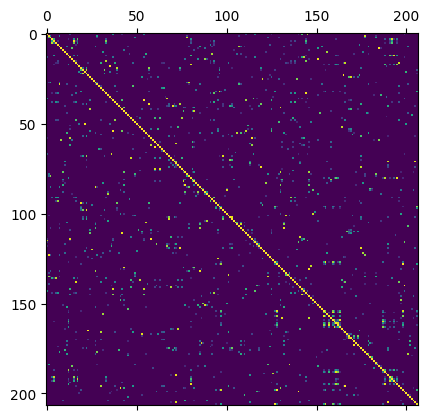

Sensor 773869 speed at 2012-03-01T00:00:00.000000000: 64.375
(34272, 207)
769847 {'sensor_id': '769847', 'ts_matrix_index': 121, 'position_info': 'Available via Adjacency Weights'}


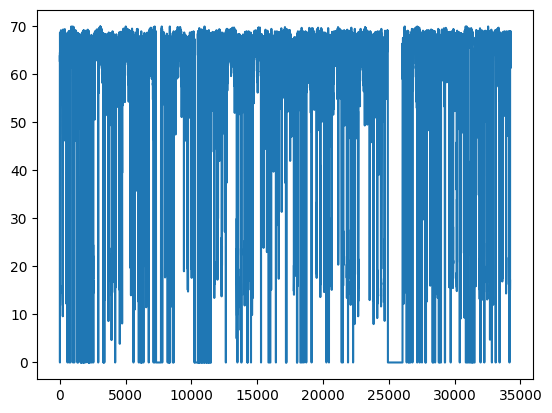

In [ ]:
import pickle
import numpy as np
import pandas as pd

import h5py

import matplotlib.pyplot as plt


def load_graph_structure(pkl_path):
    """
    Loads the pickle file and extracts node mappings and adjacency matrix.
    """
    with open(pkl_path, 'rb') as f:
        try:
            # Depending on how the pkl was saved, it might require latin1 encoding
            pickle_data = pickle.load(f, encoding='latin1')
        except UnicodeDecodeError:
            pickle_data = pickle.load(f)
            
    # Expecting: sensor_ids, sensor_id_to_ind, adj_mx
    sensor_ids, sensor_id_to_ind, adj_mx = pickle_data
    
    print("--- Graph Metadata ---")
    print(f"Total Nodes (Sensors): {len(sensor_ids)}")
    print(f"Adjacency Matrix Shape: {adj_mx.shape}\n")
    
    # Create a clean node registry list
    nodes_list = []
    for sensor_id in sensor_ids:
        matrix_idx = sensor_id_to_ind[str(sensor_id)] # standard dictionary lookup
        
        # NOTE: Standard METR-LA doesn't always embed XY coordinates inside the .pkl.
        # It relies on the adjacency matrix distances. Position is marked as 'Inferred via Matrix'.
        node_info = {
            "sensor_id": sensor_id,
            "ts_matrix_index": matrix_idx,
            "position_info": "Available via Adjacency Weights" 
        }
        nodes_list.append(node_info)
        
    return nodes_list, adj_mx

def load_time_series(h5_path):
    """
    Loads METR-LA.h5 with minimal dependencies using h5py.
    Bypasses pandas.read_hdf() to avoid the 'pytables' requirement.
    """
    with h5py.File(h5_path, 'r') as f:
        # Inspect what is inside the HDF5 structure if needed:
        # print("Keys in HDF5:", list(f.keys())) # usually ['df']
        
        # Access the main dataframe group
        df_group = f['df']
        
        # 1. Extract the raw traffic speed/volume values matrix
        # In Pandas HDF5 formats, 'block0_values' usually holds the float matrix
        raw_values = df_group['block0_values'][:]
        
        # 2. Extract the column names (Sensor IDs)
        sensor_ids = df_group['axis0'][:]
        # Decode bytes to strings if they are stored as binary
        sensor_ids = [s.decode('utf-8') if isinstance(s, bytes) else str(s) for s in sensor_ids]
        
        # 3. Extract the index (Timestamps)
        # Pandas often stores timestamps as 64-bit integers (nanoseconds since epoch)
        timestamps_raw = df_group['axis1'][:]
        # Convert to a human-readable numpy datetime array
        timestamps = np.array(timestamps_raw, dtype='datetime64[ns]')

    print("--- Time Series Metadata (Light Load) ---")
    print(f"Data Matrix Shape: {raw_values.shape} (Timesteps x Sensors)")
    print(f"Total Sensors Extracted: {len(sensor_ids)}")
    print(f"Time Range: {timestamps[0]} to {timestamps[-1]}\n")
    
    return raw_values, sensor_ids, timestamps




dataset_root_path = "/users/michal/datasets/metr-la/"


# 1. Load Graph Parts
nodes_list, adjacency_matrix = load_graph_structure(dataset_root_path + 'adj_METR-LA.pkl')

# 2. Load Time Series Data
traffic_matrix, sensors_ids, timeline = load_time_series(dataset_root_path + 'METR-LA.h5')


def get_traffic_snapshot(time_step):
    data = traffic_matrix[time_step, :]
    connections = adjacency_matrix

    return data, connections


# Print info of the first node as a sanity check

print(adjacency_matrix.shape)
plt.matshow(adjacency_matrix, cmap='viridis')
plt.show()


print(f"Sensor {sensors_ids[0]} speed at {timeline[0]}: {traffic_matrix[0, 0]}")

print(traffic_matrix.shape)

plt.plot(traffic_matrix[:, 0])  # Plot the first sensor's time series

print(sensors_ids[121], nodes_list[121])


